# 05 · Destinos sustantivos y soporte temporal — Bogotá 2023

**Objetivo.** Definir de forma reproducible destinos de **trabajo**, **educación** y **salud** a partir del motivo declarado del viaje, medir su soporte territorial y temporal, y decidir si pueden emplearse como conjuntos absorbentes en el análisis de primera llegada.

Esta es la **Compuerta 6**. Todavía no compara grupos sociales ni interpreta causalmente la localización de oportunidades. Los destinos derivados de la encuesta representan **oportunidades reveladas por viajes observados**, no un censo completo de establecimientos.


In [1]:
%pip -q install pandas pyarrow numpy matplotlib seaborn


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import os
import re
import shutil
import unicodedata
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate6"
OUT = ROOT / "outputs/bogota_em2023/gate6"
DRIVE_BASE = Path(
    "/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023"
)
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = (
    "https://observatorio.movilidadbogota.gov.co/sites/default/files/"
    "2025-09/05_Base%20datos%20procesada%20EODH.zip"
)
RANDOM_SEED = 202309
TARGET_PURPOSES = ("employment", "education", "health")
TARGET_CUMULATIVE_SHARES = (0.50, 0.80)
MIN_DESTINATION_SAMPLE = 5
MIN_DESTINATION_ESS = 3.0

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

gate5_override = os.environ.get("GATE5_DIR_OVERRIDE")
GATE5_DIR = Path(gate5_override) if gate5_override else DRIVE_BASE / "results/gate5"
GATE5_PATH = GATE5_DIR / "gate_5.json"
if not GATE5_PATH.exists():
    raise FileNotFoundError(f"No se encontró la Compuerta 5: {GATE5_PATH}")

gate5 = json.loads(GATE5_PATH.read_text(encoding="utf-8"))
gate5_status = gate5.get("gate", gate5)
if not bool(gate5_status.get("gate_5_passed", False)):
    raise RuntimeError("La Compuerta 5 no fue aprobada.")

print("Gate 5:", GATE5_PATH)
print("Salida:", OUT)


Mounted at /content/drive
Gate 5: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate5/gate_5.json
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate6


## 1. Recuperación de la tabla de viajes

Se reutiliza el ZIP oficial ya almacenado en Drive. Si no está disponible, Colab solicita cargarlo manualmente; no intenta descargarlo automáticamente del portal que previamente cerró conexiones.


In [3]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def upload_archive(destination):
    from google.colab import files

    print("Descargue el ZIP en el navegador si no lo conserva:")
    print(SOURCE_URL)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un archivo ZIP.")
    name, content = next(iter(uploaded.items()))
    temporary = destination.with_suffix(".zip.upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{name} no es un ZIP válido.")
    temporary.replace(destination)
    return "manual_upload"


archive = RAW / "processed_edoh.zip"
drive_archive = DRIVE_BASE / "processed_edoh.zip"
if valid_zip(archive):
    retrieval_method = "runtime_cache"
elif valid_zip(drive_archive):
    shutil.copy2(drive_archive, archive)
    retrieval_method = "google_drive_cache"
else:
    retrieval_method = upload_archive(archive)
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive, drive_archive)


def extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        with zipfile.ZipFile(current) as zipped:
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            nested_signature = (str(nested.resolve()), str(nested_target.resolve()))
            if nested_signature not in visited:
                queue.append((nested, nested_target))


extract_recursive(archive, INTERIM / "processed_edoh")
source_manifest = pd.DataFrame([{
    "source_id": "processed_edoh",
    "url": SOURCE_URL,
    "path": str(archive),
    "bytes": int(archive.stat().st_size),
    "sha256": sha256(archive),
    "retrieval_method": retrieval_method,
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}])
source_manifest.to_csv(OUT / "source_manifest.csv", index=False)
display(source_manifest)


,source_id,url,path,bytes,sha256,retrieval_method,generated_utc
0,processed_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,88826883,2509410f39713de4768872952e75e95809a99d7edf5b65...,google_drive_cache,2026-09-10T22:12:53.865473+00:00


## 2. Variables analíticas

La clasificación se realiza sobre las etiquetas publicadas, conservando una tabla completa de trazabilidad. Se usan expresiones preespecificadas y mutuamente excluyentes; cualquier etiqueta no reconocida queda como `other` y nunca se incorpora silenciosamente a un destino esencial.


In [4]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_")


def clean_key(series):
    cleaned = series.astype("string").str.strip()
    cleaned = cleaned.str.replace(r"\.0$", "", regex=True)
    invalid = cleaned.map(normalize).isin(
        ["", "nan", "none", "na", "no_aplica", "sin_informacion"]
    )
    return cleaned.mask(invalid)


def canonical_utam(series):
    cleaned = clean_key(series)

    def canonical(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        upr = re.fullmatch(r"UPR0*(\d+)", text)
        if upr:
            return f"UPR{int(upr.group(1)):04d}"
        utam = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        if utam:
            return f"UTAM{int(utam.group(1)):03d}"
        return text

    return cleaned.map(canonical).astype("string")


def parse_number(series):
    raw = series.astype("string").str.strip()
    comma_share = float(raw.str.contains(",", regex=False, na=False).mean())
    if comma_share > 0.05:
        raw = raw.str.replace(".", "", regex=False)
        raw = raw.str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")


def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            delimiter = csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
            return encoding, delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"No fue posible detectar el formato: {path}")


csv_paths = list((INTERIM / "processed_edoh").rglob("*.csv"))
trip_paths = [
    path for path in csv_paths
    if "viaje" in normalize(path.stem) and "etapa" not in normalize(path.stem)
]
if not trip_paths:
    raise FileNotFoundError("No se encontró el módulo CSV de viajes.")
trip_path = sorted(trip_paths, key=lambda path: (len(path.parts), len(path.name)))[0]

encoding, delimiter = csv_format(trip_path)
header = pd.read_csv(trip_path, sep=delimiter, encoding=encoding, nrows=0)
column_map = {normalize(column): column for column in header.columns}
desired = [
    "key_viaje", "motivo_viaje", "utam_des", "fexp_vj", "duracion_min",
    "sexo", "estra_hg", "hora_ini", "modo_principal_agrupado",
]
missing = sorted(set(desired) - set(column_map))
if missing:
    raise KeyError(f"Faltan columnas requeridas en viajes: {missing}")

trips = pd.read_csv(
    trip_path,
    sep=delimiter,
    encoding=encoding,
    usecols=[column_map[column] for column in desired],
    dtype="string",
    low_memory=False,
)
trips.columns = [normalize(column) for column in trips.columns]
trips["utam_destination"] = canonical_utam(trips["utam_des"])
trips["weight"] = parse_number(trips["fexp_vj"])
trips["duration_min"] = parse_number(trips["duracion_min"])
trips["purpose_label"] = trips["motivo_viaje"].astype("string").str.strip()
trips["purpose_normalized"] = trips["purpose_label"].map(normalize)


PURPOSE_PATTERNS = {
    "employment": r"trabaj|empleo|laboral",
    "education": r"estudi|educa|coleg|univers|jardin|escuela",
    "health": r"salud|medic|hospital|clinic|consulta|terapia",
}


def classify_purpose(value):
    matches = [
        purpose for purpose, pattern in PURPOSE_PATTERNS.items()
        if re.search(pattern, value)
    ]
    if len(matches) > 1:
        return "ambiguous"
    return matches[0] if matches else "other"


trips["purpose_group"] = trips["purpose_normalized"].map(classify_purpose)
valid = trips[trips["weight"].gt(0)].copy()
valid["weight_sq"] = valid["weight"] ** 2
valid["weighted_duration"] = valid["weight"] * valid["duration_min"]

taxonomy = (
    valid.groupby(["purpose_label", "purpose_normalized", "purpose_group"],
                  observed=True, dropna=False)
    .agg(
        sampled_trips=("weight", "size"),
        weighted_trips=("weight", "sum"),
        destination_nonmissing_share=("utam_destination", lambda x: x.notna().mean()),
        duration_nonmissing_share=("duration_min", lambda x: x.notna().mean()),
    )
    .reset_index()
    .sort_values("weighted_trips", ascending=False)
)
taxonomy.to_csv(OUT / "purpose_taxonomy.csv", index=False)
print("Archivo de viajes:", trip_path.relative_to(INTERIM))
display(taxonomy)


Archivo de viajes: processed_edoh/05_Base datos procesada EODH/CSV/d. Modulo viajes.csv


,purpose_label,purpose_normalized,purpose_group,sampled_trips,weighted_trips,destination_nonmissing_share,duration_nonmissing_share
11,A regresar al hogar,a_regresar_al_hogar,other,47672,7938013.5,1.000000,1.0
12,A trabajar,a_trabajar,employment,20821,3393451.3,0.961193,1.0
0,A Estudiar,a_estudiar,education,9417,1528957.8,0.986620,1.0
9,A realizar algún trámite personal,a_realizar_algun_tramite_personal,other,4904,828608.1,0.983687,1.0
10,A realizar compras,a_realizar_compras,other,4662,773240.7,0.990347,1.0
2,A acompañar a alguien sin remuneración,a_acompanar_a_alguien_sin_remuneracion,other,3899,770024.4,0.989741,1.0
4,A asuntos médicos personales,a_asuntos_medicos_personales,health,3669,624179.0,0.994276,1.0
13,A visitar a alguien,a_visitar_a_alguien,other,1450,242987.5,0.973793,1.0
8,A realizar actividades recreativas y culturales,a_realizar_actividades_recreativas_y_culturales,other,1235,199602.0,0.980567,1.0
7,A realizar actividades físicas y/o deportivas,a_realizar_actividades_fisicas_y_o_deportivas,other,997,176531.1,0.982949,1.0


## 3. Soporte por propósito y destino

Para cada propósito y UTAM de destino se calculan viajes muestrales, viajes expandidos, tamaño efectivo de Kish y duración media ponderada. Una UTAM tiene soporte si registra al menos 5 viajes y tamaño efectivo al menos 3.


In [5]:
purpose_trips = valid[
    valid["purpose_group"].isin(TARGET_PURPOSES)
    & valid["utam_destination"].notna()
].copy()

destination_support = (
    purpose_trips.groupby(["purpose_group", "utam_destination"], observed=True)
    .agg(
        sampled_trips=("weight", "size"),
        weighted_trips=("weight", "sum"),
        sum_weight_sq=("weight_sq", "sum"),
        weighted_duration=("weighted_duration", "sum"),
        duration_weight=(
            "weight", lambda x: x[purpose_trips.loc[x.index, "duration_min"].notna()].sum()
        ),
    )
    .reset_index()
)
destination_support["effective_sample_size"] = (
    destination_support["weighted_trips"] ** 2
    / destination_support["sum_weight_sq"].replace(0, np.nan)
)
destination_support["mean_duration_min"] = (
    destination_support["weighted_duration"]
    / destination_support["duration_weight"].replace(0, np.nan)
)
destination_support["supported"] = (
    destination_support["sampled_trips"].ge(MIN_DESTINATION_SAMPLE)
    & destination_support["effective_sample_size"].ge(MIN_DESTINATION_ESS)
)
destination_support = destination_support.drop(columns=[
    "sum_weight_sq", "weighted_duration", "duration_weight"
])

summary_rows = []
for purpose in TARGET_PURPOSES:
    all_purpose = valid[valid["purpose_group"].eq(purpose)]
    mapped = purpose_trips[purpose_trips["purpose_group"].eq(purpose)]
    support = destination_support[destination_support["purpose_group"].eq(purpose)]
    supported_weight = support.loc[support["supported"], "weighted_trips"].sum()
    duration_valid = all_purpose["duration_min"].notna() & all_purpose["duration_min"].gt(0)
    summary_rows.append({
        "purpose_group": purpose,
        "sampled_trips": int(len(all_purpose)),
        "weighted_trips": float(all_purpose["weight"].sum()),
        "destination_utam_coverage": float(
            all_purpose["utam_destination"].notna().mean()
        ),
        "positive_duration_coverage": float(duration_valid.mean()),
        "observed_destination_nodes": int(support["utam_destination"].nunique()),
        "supported_destination_nodes": int(support["supported"].sum()),
        "supported_weight_coverage": float(
            supported_weight / mapped["weight"].sum() if len(mapped) else 0
        ),
    })

purpose_summary = pd.DataFrame(summary_rows)
destination_support.to_csv(OUT / "purpose_destination_support.csv", index=False)
purpose_summary.to_csv(OUT / "purpose_summary.csv", index=False)
display(purpose_summary)


,purpose_group,sampled_trips,weighted_trips,destination_utam_coverage,positive_duration_coverage,observed_destination_nodes,supported_destination_nodes,supported_weight_coverage
0,employment,21115,3444837.6,0.961402,1.0,141,139,0.999870
1,education,9417,1528957.8,0.986620,1.0,140,134,0.997861
2,health,3669,624179.0,0.994276,1.0,137,109,0.983277


## 4. Conjuntos absorbentes preespecificados

Dentro de las UTAM con soporte se ordena el flujo del propósito y se selecciona el conjunto mínimo que acumula 50 % y 80 % de la masa soportada. Esto produce dos escalas de oportunidad revelada: **núcleo** y **extendida**.


In [6]:
target_rows = []
concentration_rows = []
for purpose in TARGET_PURPOSES:
    ranked = destination_support[
        destination_support["purpose_group"].eq(purpose)
        & destination_support["supported"]
    ].sort_values("weighted_trips", ascending=False).copy()
    total_supported = float(ranked["weighted_trips"].sum())
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["cumulative_supported_share"] = (
        ranked["weighted_trips"].cumsum() / total_supported
    )

    for cutoff in TARGET_CUMULATIVE_SHARES:
        crossing = np.flatnonzero(
            ranked["cumulative_supported_share"].to_numpy() >= cutoff
        )
        number = int(crossing[0] + 1) if len(crossing) else int(len(ranked))
        label = "core_50" if cutoff == 0.50 else "extended_80"
        selected = ranked.head(number)
        for row in selected.itertuples(index=False):
            target_rows.append({
                "purpose_group": purpose,
                "target_definition": label,
                "target_share": float(cutoff),
                "utam": row.utam_destination,
                "rank": int(row.rank),
                "weighted_trips": float(row.weighted_trips),
                "effective_sample_size": float(row.effective_sample_size),
                "cumulative_supported_share": float(row.cumulative_supported_share),
            })
        concentration_rows.append({
            "purpose_group": purpose,
            "target_definition": label,
            "target_nodes": int(number),
            "selected_supported_share": float(
                selected["weighted_trips"].sum() / total_supported
            ),
        })

target_sets = pd.DataFrame(target_rows)
target_summary = pd.DataFrame(concentration_rows)
target_sets.to_csv(OUT / "purpose_target_sets.csv", index=False)
target_summary.to_csv(OUT / "purpose_target_summary.csv", index=False)
display(target_summary)


,purpose_group,target_definition,target_nodes,selected_supported_share
0,employment,core_50,30,0.508192
1,employment,extended_80,69,0.805700
2,education,core_50,29,0.502319
3,education,extended_80,66,0.805499
4,health,core_50,19,0.501930
5,health,extended_80,50,0.801309


## 5. Concentración espacial

Las curvas muestran qué proporción del flujo de cada propósito se concentra en las UTAM con mayor demanda. No son todavía mapas de oferta institucional.


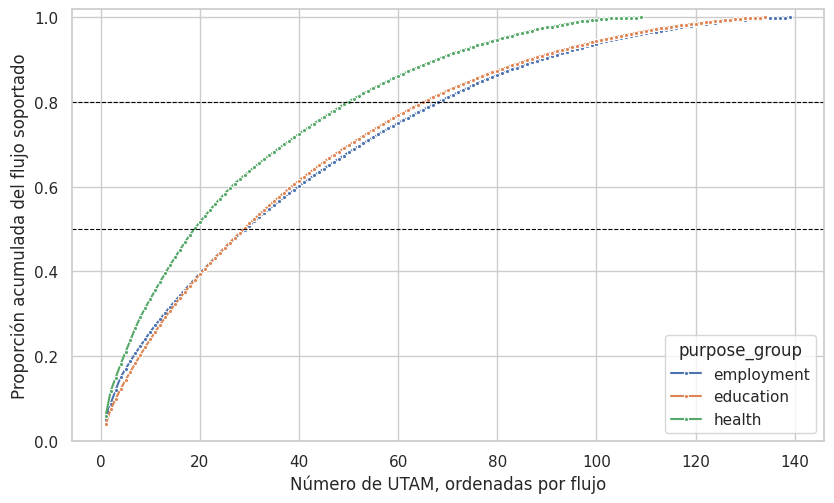

In [7]:
curve_rows = []
for purpose in TARGET_PURPOSES:
    ranked = destination_support[
        destination_support["purpose_group"].eq(purpose)
        & destination_support["supported"]
    ].sort_values("weighted_trips", ascending=False).copy()
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["cumulative_share"] = (
        ranked["weighted_trips"].cumsum() / ranked["weighted_trips"].sum()
    )
    ranked["purpose_group"] = purpose
    curve_rows.append(ranked[["purpose_group", "rank", "cumulative_share"]])

concentration_curves = pd.concat(curve_rows, ignore_index=True)
sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.lineplot(
    data=concentration_curves,
    x="rank",
    y="cumulative_share",
    hue="purpose_group",
    marker="o",
    markersize=3,
    ax=ax,
)
for cutoff in TARGET_CUMULATIVE_SHARES:
    ax.axhline(cutoff, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Número de UTAM, ordenadas por flujo")
ax.set_ylabel("Proporción acumulada del flujo soportado")
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(OUT / "purpose_destination_concentration.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Compuerta 6

La compuerta exige identificación inequívoca de los tres propósitos, cobertura espacial y temporal suficiente, soporte efectivo y conjuntos objetivo no degenerados.


In [8]:
thresholds = {
    "minimum_sampled_trips_per_purpose": 300,
    "minimum_destination_utam_coverage": 0.95,
    "minimum_positive_duration_coverage": 0.90,
    "minimum_supported_weight_coverage": 0.75,
    "minimum_core_target_nodes": 3,
    "minimum_extended_target_nodes": 5,
}

ambiguous_weight_share = float(
    valid.loc[valid["purpose_group"].eq("ambiguous"), "weight"].sum()
    / valid["weight"].sum()
)

checks = {
    "gate5_dependency_valid": bool(gate5_status.get("gate_5_passed", False)),
    "required_purposes_detected": bool(
        set(TARGET_PURPOSES).issubset(set(purpose_summary["purpose_group"]))
    ),
    "purpose_classification_unambiguous": bool(ambiguous_weight_share == 0),
    "sample_size_valid": bool(
        purpose_summary["sampled_trips"].ge(
            thresholds["minimum_sampled_trips_per_purpose"]
        ).all()
    ),
    "destination_coverage_valid": bool(
        purpose_summary["destination_utam_coverage"].ge(
            thresholds["minimum_destination_utam_coverage"]
        ).all()
    ),
    "duration_coverage_valid": bool(
        purpose_summary["positive_duration_coverage"].ge(
            thresholds["minimum_positive_duration_coverage"]
        ).all()
    ),
    "destination_support_valid": bool(
        purpose_summary["supported_weight_coverage"].ge(
            thresholds["minimum_supported_weight_coverage"]
        ).all()
    ),
    "core_targets_valid": bool(
        target_summary.loc[
            target_summary["target_definition"].eq("core_50"), "target_nodes"
        ].ge(thresholds["minimum_core_target_nodes"]).all()
    ),
    "extended_targets_valid": bool(
        target_summary.loc[
            target_summary["target_definition"].eq("extended_80"), "target_nodes"
        ].ge(thresholds["minimum_extended_target_nodes"]).all()
    ),
}
checks["gate_6_passed"] = bool(all(checks.values()))

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "source_sha256": str(source_manifest.loc[0, "sha256"]),
    "purpose_patterns": PURPOSE_PATTERNS,
    "target_purposes": list(TARGET_PURPOSES),
    "target_cumulative_shares": [float(x) for x in TARGET_CUMULATIVE_SHARES],
    "destination_support_rules": {
        "minimum_sampled_trips": int(MIN_DESTINATION_SAMPLE),
        "minimum_effective_sample_size": float(MIN_DESTINATION_ESS),
    },
    "thresholds": {key: float(value) for key, value in thresholds.items()},
    "ambiguous_weight_share": ambiguous_weight_share,
    "purpose_summary": json.loads(purpose_summary.to_json(orient="records")),
    "target_summary": json.loads(target_summary.to_json(orient="records")),
    "gate": checks,
    "interpretation_scope": (
        "Survey-revealed destination opportunities; not a complete facility census"
    ),
}
(OUT / "gate_6.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series(checks, name="result").to_csv(OUT / "gate_6_checks.csv")
display(pd.Series(checks, name="result"))

persistent_out = DRIVE_BASE / "results/gate6"
persistent_out.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent_out / artifact.name)

print("Compuerta 6:", "APROBADA" if checks["gate_6_passed"] else "NO APROBADA")
print("Copia persistente:", persistent_out)


,result
gate5_dependency_valid,True
required_purposes_detected,True
purpose_classification_unambiguous,True
sample_size_valid,True
destination_coverage_valid,True
duration_coverage_valid,True
destination_support_valid,True
core_targets_valid,True
extended_targets_valid,True
gate_6_passed,True


Compuerta 6: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate6


## Interpretación y siguiente paso

- Si la Compuerta 6 pasa, los conjuntos `core_50` y `extended_80` podrán reemplazar los objetivos técnicos del notebook 04.
- La duración observada describe los viajes que alcanzaron cada destino; no debe sumarse directamente a un tiempo de primer paso sin especificar un modelo de recompensa o semi-Markov.
- El siguiente notebook estimará primera llegada hacia trabajo, educación y salud, comparará las dos definiciones de objetivo y cuantificará sensibilidad.
- La validación con registros abiertos de establecimientos se realizará por separado para evitar presentar demanda observada como oferta completa.
